# Laboratory 4: Reinforcement learning
     


### Golf environment

We consider a very simple golf simulator with one continuous dimension. The goal is to reach the hole in the minimum amount of plays. We let $x \in [0,450]$ be the continuous random variable encoding the position of the ball in the golf course. We consider 4 golf courses, which differ in the position of the hole and wind intensity. The maximum length across all golf courses is of 450 meters.

There are 6 different actions corresponding to 6 golf clubs:
*   Long range (action 0 - more precise, action 1 - less precise)
*   Medium range (action 2 - more precise, action 3 - less precise)
*   Short range (action 4 - more precise, action 5 - less precise)

The function `golf_env_step(env, x, a)` provides a simulator for this game, where `env` is a number (0-3) corresponding to a given golf course, `x` is the current location of the ball, and `a` the action. The function returns the new location of the ball and the cost (0 if it entered the hole, 1 otherwise). When the ball enters the hole, the cost is 0 and the environment resets to its initial configuration where the ball is in position 0 again.

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

def golf_env_step(env, x, a):

    if env == 0:
        xgoal = 200
        wind = -10
    elif env == 1:
        xgoal = 200
        wind = 10
    elif env == 2:
        xgoal = 400
        wind = -20
    elif env == 3:
        xgoal = 400
        wind = +10

    if a == 0:
        x = x + np.sign(xgoal-x) * (np.random.normal() * 10 + 100) + wind
    elif a == 1:
        x = x + np.sign(xgoal-x) * (np.random.normal() * 30 + 150) + wind
    elif a == 2:
        x = x + np.sign(xgoal-x) * (np.random.normal() * 5 + 50) + wind/2
    elif a == 3:
        x = x + np.sign(xgoal-x) * (np.random.normal() * 15 + 75) + wind/2
    elif a == 4:
        x = x + np.sign(xgoal-x) * (np.random.normal() * 1) + min((xgoal-x),10)
    elif a == 5:
        x = x + np.sign(xgoal-x) * (np.random.normal() * 4 + 2 * min((xgoal-x),20)) + wind/4

    x = np.double(x)
    if x < 0:
        x = 0
    elif x > 450:
        x = 450

    if np.abs(x-xgoal) < 2:
        c = 0
        x = 0
    else:
        c = 1

    return x, c

In [3]:
ENV = 2 # The golf course to consider.
Na = 6

## Learning with function approximation. ##

When the number of states is very large, or the problem is continuous, a discretization approach might not be enough. In those cases, we need to resort to function approximation to approximate the Q-values. Consider the following parametrization of the Q-function

$$Q_\theta(x,a) = \theta^\top f(x)$$

where: (i) $\theta \in \mathbb{R}^{2\times N_a}$ are the learnable parameters for each of the actions, where $N_a$ is the number of actions; and (ii) the features vector is given by

$$f(x) = \bigg[\frac{x}{450},1\bigg]^\top.$$

We follow a fitted Q-iteration approach where we first collect data by interacting with the environment, then use the collected data to build targets for the regression problem, and finally solve a regression problem to find the new set of parameters $\theta^\text{new}$ for each of the actions.

In the following activities we will implement each step separately.

## Activity 1 ##
Implement function `x_to_features`, which receives a vector $x$ of size $(N,)$ containing a set of $N$ positions $x$ and returns a matrix with size $(2 \times N)$ where each column contains the feature associated with each of the $x$ points.

`x_to_features(x)`

* x: np.array containing a set of $x$ points


In [4]:
def x_to_features(x):
    f1 = x / 450.0
    
    # bias
    f2 = np.ones_like(x)
    
    features = np.array([f1, f2])
    
    return features

x_test_1 = np.array([311.9])
f_test_1 = x_to_features(x_test_1)
print(f_test_1)
print(f_test_1.shape)

x_test_2 = np.array([0.0, 86.6, 148.1, 231.5, 311.9])
f_test_2 = x_to_features(x_test_2)
print(f_test_2)
print(f_test_2.shape)

[[0.69311111]
 [1.        ]]
(2, 1)
[[0.         0.19244444 0.32911111 0.51444444 0.69311111]
 [1.         1.         1.         1.         1.        ]]
(2, 5)


The following code



```
x_test_1 = np.array([311.9])
f_test_1 = x_to_features(x_test_1)
print(f_test_1)
print(f_test_1.shape)

x_test_2 = np.array([0.0, 86.6, 148.1, 231.5, 311.9])
f_test_2 = x_to_features(x_test_2)
print(f_test_2)
print(f_test_2.shape)
```


should give the result


```
[[0.69311111]
 [1.        ]]
(2, 1)
[[0.         0.19244444 0.32911111 0.51444444 0.69311111]
 [1.         1.         1.         1.         1.        ]]
(2, 5)
```





## Activity 2 ##
We now implement function `updateCoef`, which performs a step of the fitted-Q-iteration (FQI) algorithm. The function receives a trajectory `T` and set of parameters $\theta$ and returns the updated parameters $\theta^\text{new}$, which correspond to the new parameters after a single learning step of the fitted-Q-iteration algorithm.

The function should perform the updates separately for each action $a$. First, the function should select all transitions $(x_t,a_t,c_t, x_{t+1})$ associated with action $a$, i.e, select all transitions $(x_t,a_t,c_t, x_{t+1})$ such that $a_t=a$. Then, we need to calculate the regression targets $y_a$ for each of the transition tuples associated with action $a$ as $y_{a,t} = c_t + \gamma \min_a \{ \theta^\top f(x_{t+1}) \}$. Finally, for the transition tuples associated with action $a$, we compute the new set of parameters $\theta^\text{new}$ by solving the regression problem with inputs $f(x_t)$ and target values $y_a$.

The new parameters $\theta^\text{new}$ can be calculated using the following least-squares solution: $\theta_a^\text{new} = (f_a^\top f_a)^{-1} f_a^\top y_a$, where $\theta_a^\text{new}\in\mathbb{R}^2$ is $a$-th column of $\theta^\text{new}$, $f_a \in \mathbb{R}^{N_a\times2}$ is the feature matrix of the inputs $x_t$ associated with action $a$, and $y_a \in \mathbb{R}^{N_a}$ is the vector of targets associated with action $a$ ($N_a$ is the number of transitions in `T` associated with action $a$). We then repeat for each of the actions.

```python
updateCoef(T, theta, gamma = 0.9, Na = 6)
```

* `T`: a trajectory of transitions
* `theta`: the set of learnable parameters
* `gamma`: discount factor
* `Na`: the number of actions




In [5]:
def updateCoef(T, theta, gamma = 0.9, Na = 6):
    next_theta = np.copy(theta)

    for a in range(Na):
        # filter transitions associated with action a
        action_mask = T[:, 1] == a
        transitions = T[action_mask]
        
        if len(transitions) == 0:
            continue
            
        x_t = transitions[:, 0]
        c_t = transitions[:, 2]
        x_next = transitions[:, 3]
        
        # calculate the regression targets (y_a)
        f_next = x_to_features(x_next) 
        
        Q_next = theta.T @ f_next
        # minimum Q-value over actions
        min_Q_next = np.min(Q_next, axis=0)
        
        y_a = c_t + gamma * min_Q_next
        
        # Least Squares
        f_a = x_to_features(x_t).T
        
        next_theta[:, a] = np.linalg.pinv(f_a.T @ f_a) @ f_a.T @ y_a

    return next_theta

np.random.seed(1640)
theta = np.ones([2,Na]) / Na
T = np.array([[  0.        ,   0.        ,   1.        ,  77.97101407],
       [ 77.97101407,   0.        ,   1.        , 147.42896569],
       [147.42896569,   0.        ,   1.        , 216.11126557],
       [216.11126557,   0.        ,   1.        , 308.66565669],
       [308.66565669,   0.        ,   1.        , 373.28914596]])
updated_theta = updateCoef(T, theta, Na)
print(updated_theta)
print(updated_theta.shape)

[[0.99098513 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
 [2.16891195 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]]
(2, 6)


The following code



```
np.random.seed(1640)
theta = np.ones([2,Na]) / Na
T = np.array([[  0.        ,   0.        ,   1.        ,  77.97101407],
       [ 77.97101407,   0.        ,   1.        , 147.42896569],
       [147.42896569,   0.        ,   1.        , 216.11126557],
       [216.11126557,   0.        ,   1.        , 308.66565669],
       [308.66565669,   0.        ,   1.        , 373.28914596]])
updated_theta = updateCoef(T, theta, Na)
print(updated_theta)
print(updated_theta.shape)
```


should give the result


```
[[0.99098513 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
 [2.16891195 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]]
(2, 6)
```





You can now use the following code below to run multiple steps of the fitted-Q-iteration algorithm.

In [6]:
#alternative to match with reinforce
def FittedQI(env, gamma=0.99, Niter=2000, MaxSteps=30, theta = np.ones([2,Na]) / Na):
    egreedy = 0.1
    T = []
    x = 0
    LogFQI = []

    _, nA = theta.shape

    for i in range(Niter):
        # 1. Generate a full trajectory
        x = 0
        C = 0
        for _ in range(MaxSteps):

            if np.random.rand() < egreedy:
                a = np.random.randint(0, nA)
            else:
                a = np.argmin(x_to_features(np.array([x])).T@theta)

            xn,c = golf_env_step(ENV, x, a)
            C = C + c
            T.append([x,a,c,xn])
            x = xn
            if c == 0:
                break

        LogFQI.append(C)
        #
        if len(T)%100==0:
            theta = updateCoef(np.array(T), theta, gamma = gamma, Na = nA)
            #T = []
    return theta, LogFQI, T




Text(0, 0.5, 'length of episode')

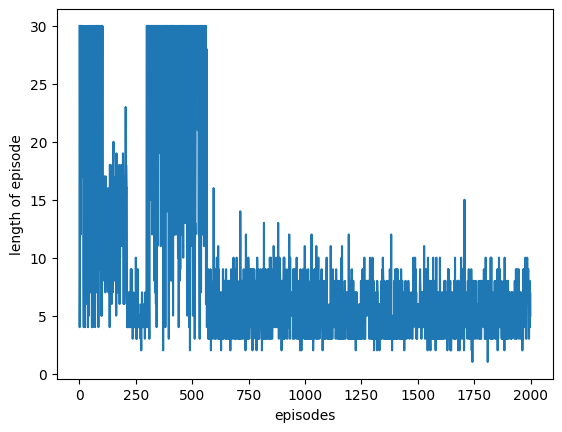

In [7]:
#Verify if it works
theta, LogFQI, T = FittedQI(ENV, gamma=0.99, Niter=2000, MaxSteps=30)
plt.plot(LogFQI)
plt.xlabel('episodes')
plt.ylabel('length of episode')

(2, 100)


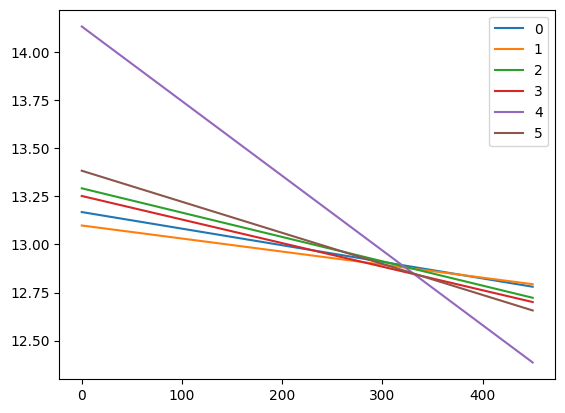

In [8]:
#This code allows visualizing the policy

xs = np.linspace(0.0, 450.0, 100)
ftoplot = np.concatenate([x_to_features(np.array([x])) for x in xs], axis=1)
print(ftoplot.shape)
plt.plot(xs, ftoplot.T@theta)
plt.legend(['0','1','2','3','4','5'])
# plt.plot(np.min(ftoplot.T@theta,axis=1))


## REINFORCE Algorithm ##

REINFORCE is a Monte Carlo policy gradient algorithm that directly optimizes a parameterized policy $\pi_\theta(a|s)$. The goal is to minimize the expected cost $J(\theta) = \mathbb{E}[G_0]$. The parameters are updated using the gradients of the log-probability of the actions taken, weighted by the observed returns $G_t$:

$$\theta_{t+1} = \theta_t - \alpha \gamma^t G_t \nabla_\theta \log \pi_{\theta_t}(a_t|s_t)$$

Where:
- $G_t$ is the return (sum of discounted rewards) from time $t$.
- $\pi_\theta(a|s)$ is the probability of taking action $a$ in state $s$ given parameters $\theta$.
- $\alpha$ is the learning rate.
- $\gamma$ is the discount factor.

In this environment, we can define a softmax policy over the linear features $f(x) = [x/450, 1]^\top$.

## Activity 4 ##
Implement function `softmaxProb`, that receives the current $\theta$ and feature of the state and compute the soft policy.

Implement function `reinforceUpdate`, that receives a sequence of states-actions-costs and compute the update of the $\theta$ parameters.

`softmaxProb(f, theta)`

* f - features of current state
* theta - coefficients of the policy

`reinforceUpdate(states, actions, costs, theta, lr = 0.005, gamma = 0.99)`

* states - sequence of states
* actions - sequence of actions
* costs - sequence of costs
* theta: coefficients of the policy




In [9]:
def softmaxProb(f, theta):
    # Calculate the raw logits
    logits = f @ theta
    
    # Subtract the maximum logit for numerical stability 
    logits -= np.max(logits)
    
    # Compute softmax probabilities
    exp_logits = np.exp(logits)
    probs = exp_logits / np.sum(exp_logits)
    
    return probs

def reinforceUpdate(states, actions, costs, theta, lr=0.005, gamma=0.99):
    T = len(states)
    Na = theta.shape[1]
    
    # Create a copy of theta to avoid corrupting the original params
    next_theta = np.copy(theta)
    
    for t in range(T):
        # Calculate the Return G_t
        G_t = sum((gamma ** (k - t)) * costs[k] for k in range(t, T))
        
        f_t = states[t]
        a_t = actions[t]
        
        # Get the action probabilities for the current state
        pi = softmaxProb(f_t, next_theta)
        
        # Gradient of log pi: f * (I(a==at) - pi(a|s))
        indicator = np.zeros(Na)
        indicator[a_t] = 1.0
        
        # Compute the difference term for all actions
        diff = indicator - pi
        
        grad = np.outer(f_t, diff)
        
        # Gradient descent update (according to REINFORCE formula)
        next_theta = next_theta - lr * (gamma ** t) * G_t * grad
        
    return next_theta

theta = np.array([[-2.7, -1.06, -1.2, -0.72,  6.31, -0.59],
       [-0.0047,  4.47, -1.477, 0.31, -1.47, -1.827]])
f = x_to_features(np.array([0])).flatten()
probs = softmaxProb(f, theta)
print(probs)

new_theta = reinforceUpdate( [f], [3], [1], theta)
print(new_theta)

[0.01101805 0.96703502 0.00252751 0.01509306 0.00254526 0.00178111]
[[-2.70000000e+00 -1.06000000e+00 -1.20000000e+00 -7.20000000e-01
   6.31000000e+00 -5.90000000e-01]
 [-4.64490976e-03  4.47483518e+00 -1.47698736e+00  3.05075465e-01
  -1.46998727e+00 -1.82699109e+00]]


The following code



```
theta = np.array([[-2.7, -1.06, -1.2, -0.72,  6.31, -0.59],
       [-0.0047,  4.47, -1.477, 0.31, -1.47, -1.827]])
f = x_to_features(np.array([0])).flatten()
probs = softmaxProb(f, theta)
print(probs)

new_theta = reinforceUpdate( [f], [3], [1], theta)
print(new_theta)
```


should give the result

```
[0.01101805 0.96703502 0.00252751 0.01509306 0.00254526 0.00178111]
[[-2.70000000e+00 -1.06000000e+00 -1.20000000e+00 -7.20000000e-01
   6.31000000e+00 -5.90000000e-01]
 [-4.64490976e-03  4.47483518e+00 -1.47698736e+00  3.05075465e-01
  -1.46998727e+00 -1.82699109e+00]]
```


With the data generation and the update rule, the following code will train using reinforce.

Training REINFORCE...


Text(0, 0.5, 'length of episode')

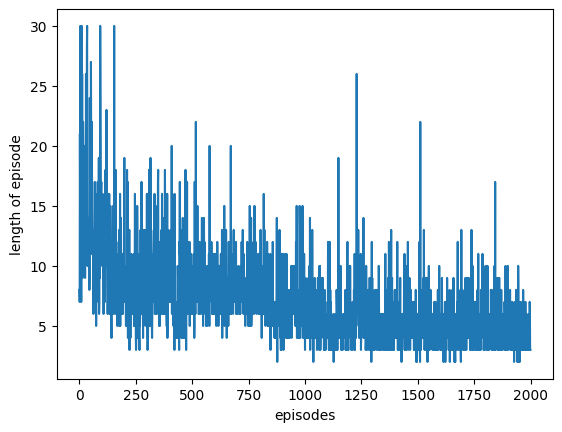

In [10]:
def reinforce(env, Na, lr=0.005, gamma=0.99, Niter=100, MaxSteps=30):
    # Initialize parameters (2 features x Na actions)
    theta = np.zeros((2, Na))
    Log = []

    for i in range(Niter):
        # 1. Generate a full trajectory
        states, actions, costs = [], [], []
        x = 0
        for _ in range(MaxSteps):
            f = x_to_features(np.array([x])).flatten()

            # Compute softmax probabilities
            probs = softmaxProb(f, theta)

            # Sample action from policy
            a = np.random.choice(Na, p=probs)

            # Step the environment
            xn, c = golf_env_step(env, x, a)

            states.append(f)
            actions.append(a)
            costs.append(c)

            x = xn
            if c == 0:
                break
        Log.append( np.sum(costs) )

        # 2. Update policy parameters
        theta = reinforceUpdate(states, actions, costs, theta, lr = lr, gamma = gamma)


    return theta, Log

# Train with REINFORCE
print("Training REINFORCE...")
theta_reinforce, LogReinforce = reinforce(env=ENV, Na=6, Niter=2000, lr=0.01)

plt.plot(LogReinforce)
plt.xlabel('episodes')
plt.ylabel('length of episode')

Text(0, 0.5, 'length of episode')

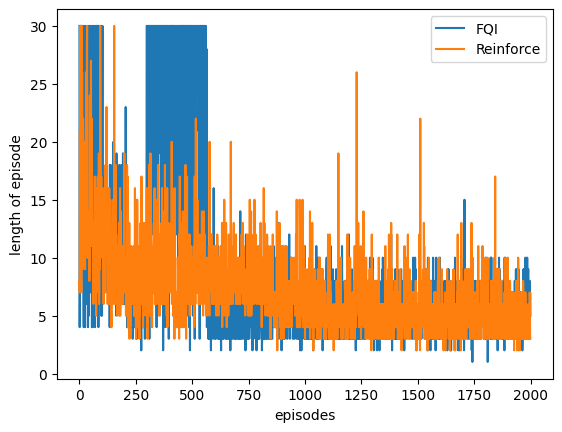

In [11]:
plt.plot(LogFQI)
plt.plot(LogReinforce)
plt.legend(['FQI','Reinforce'])
plt.xlabel('episodes')
plt.ylabel('length of episode')


## Code

Implement all functions requested at activities 1 to 4.

## Questions to be answered in the report ##

### Q1 ###
What are the limitation(s) when applying the discretized Q-learning algorithm to solve the golf problem we considered in this lab?

### Q2 ###
What are the limitation(s) when applying the fitted-Q-learning algorithm with linear function approximation (fixed features) to solve the golf problem we considered in this lab?

### Q3 ###
What algorithm provided better results? Reinforce or FQI? Justify based on the cumulative costs obtained during training.

### Q4 ###
FQI is using a matrix inversion. What alternatives exist for solving the same problem? Implement them and see if the results improve.

### Q5 ###
What is the difference in exploration strategy between the two methods? Which one explores more states and/or more uniformly?

### Q6 ###
How can you improve Reinforce? Suggest and implement one idea. Discuss the results obtained against the original implementation.

## Q4 - Code Implementation

Training FQI with Gradient Descent...


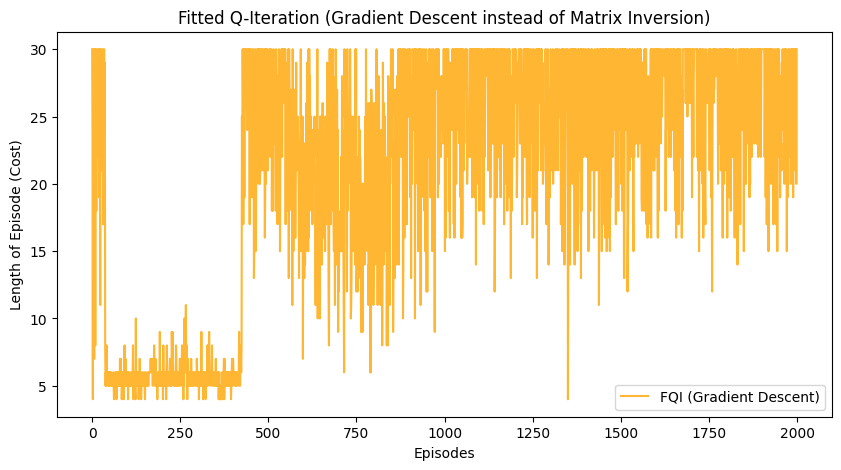

In [12]:
# --- FQI Update using Gradient Descent (Alternative to Matrix Inversion) ---
def updateCoef_GD(T, theta, gamma=0.9, Na=6, alpha=0.05, gd_iterations=50):
    next_theta = np.copy(theta)

    for a in range(Na):
        action_mask = T[:, 1] == a
        transitions = T[action_mask]
        
        if len(transitions) == 0:
            continue
            
        x_t = transitions[:, 0]
        c_t = transitions[:, 2]
        x_next = transitions[:, 3]
        
        # Calculate targets (y_a)
        f_next = x_to_features(x_next) 
        Q_next = theta.T @ f_next
        min_Q_next = np.min(Q_next, axis=0)
        y_a = c_t + gamma * min_Q_next
        
        # Current features
        f_a = x_to_features(x_t).T
        theta_a = np.copy(theta[:, a])
        
        # Gradient Descent Loop (Replaces the OLS pseudo-inverse)
        for _ in range(gd_iterations):
            predictions = f_a @ theta_a
            errors = predictions - y_a
            gradient = (f_a.T @ errors) / len(y_a)
            theta_a = theta_a - alpha * gradient
            
        next_theta[:, a] = theta_a

    return next_theta

# --- Training Loop ---
def FittedQI_GD(env, gamma=0.99, Niter=2000, MaxSteps=30):
    theta = np.ones([2, Na]) / Na
    egreedy = 0.1
    T = []
    LogFQI_GD = []
    nA = theta.shape[1]

    for i in range(Niter):
        x = 0
        C = 0
        for _ in range(MaxSteps):
            if np.random.rand() < egreedy:
                a = np.random.randint(0, nA)
            else:
                a = np.argmin(x_to_features(np.array([x])).T @ theta)

            xn, c = golf_env_step(ENV, x, a)
            C = C + c
            T.append([x, a, c, xn])
            x = xn
            if c == 0:
                break

        LogFQI_GD.append(C)
        
        # Update weights using Gradient Descent
        if len(T) % 100 == 0:
            theta = updateCoef_GD(np.array(T), theta, gamma=gamma, Na=nA)
            
    return theta, LogFQI_GD, T

print("Training FQI with Gradient Descent...")
theta_gd, LogFQI_GD, T_gd = FittedQI_GD(ENV, gamma=0.99, Niter=2000, MaxSteps=30)

plt.figure(figsize=(10, 5))
plt.plot(LogFQI_GD, label='FQI (Gradient Descent)', color='orange', alpha=0.8)
plt.xlabel('Episodes')
plt.ylabel('Length of Episode (Cost)')
plt.title('Fitted Q-Iteration (Gradient Descent instead of Matrix Inversion)')
plt.legend()
plt.show()

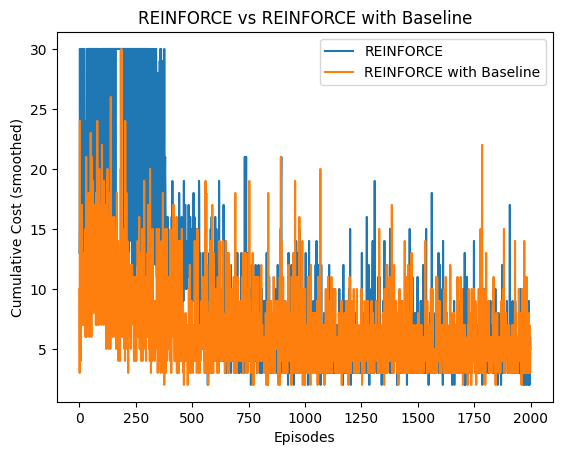

In [13]:
def reinforceUpdate_baseline(states, actions, costs, theta, lr=0.005, gamma=0.99):
    T = len(states)
    Na = theta.shape[1]
    next_theta = np.copy(theta)

    # Compute all returns G_t
    returns = []
    for t in range(T):
        G_t = sum((gamma ** (k - t)) * costs[k] for k in range(t, T))
        returns.append(G_t)

    # Baseline: mean return across the episode
    baseline = np.mean(returns)

    for t in range(T):
        G_t = returns[t]
        f_t = states[t]
        a_t = actions[t]

        pi = softmaxProb(f_t, next_theta)

        indicator = np.zeros(Na)
        indicator[a_t] = 1.0
        diff = indicator - pi
        grad = np.outer(f_t, diff)

        # Subtract baseline from return
        next_theta = next_theta - lr * (gamma ** t) * (G_t - baseline) * grad

    return next_theta


def reinforce_baseline(env, Na, lr=0.005, gamma=0.99, Niter=100, MaxSteps=30):
    theta = np.zeros((2, Na))
    Log = []

    for i in range(Niter):
        states, actions, costs = [], [], []
        x = 0
        for _ in range(MaxSteps):
            f = x_to_features(np.array([x])).flatten()
            probs = softmaxProb(f, theta)
            a = np.random.choice(Na, p=probs)
            xn, c = golf_env_step(env, x, a)
            states.append(f)
            actions.append(a)
            costs.append(c)
            x = xn
            if c == 0:
                break
        Log.append(np.sum(costs))
        theta = reinforceUpdate_baseline(states, actions, costs, theta, lr=lr, gamma=gamma)

    return theta, Log


# Train both and compare
theta_reinforce, LogReinforce = reinforce(env=ENV, Na=6, Niter=2000, lr=0.01)
theta_baseline, LogBaseline = reinforce_baseline(env=ENV, Na=6, Niter=2000, lr=0.01)

# Plot comparison
window = 50
#LogReinforce_smooth = np.convolve(LogReinforce, np.ones(window)/window, mode='valid')
#LogBaseline_smooth = np.convolve(LogBaseline, np.ones(window)/window, mode='valid')

plt.plot(LogReinforce, label='REINFORCE')
plt.plot(LogBaseline, label='REINFORCE with Baseline')
plt.xlabel('Episodes')
plt.ylabel('Cumulative Cost (smoothed)')
plt.legend()
plt.title('REINFORCE vs REINFORCE with Baseline')
plt.show()